In [1]:
import os
from matplotlib import pyplot as plt
import seaborn as sns
import random
import shutil
from torchvision import transforms, datasets, models
from PIL import Image
from torch.utils.data import random_split, DataLoader
from torch import nn, optim
import torch
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix

d:\SVNIT\Semester - 6\Deep Learning\Practicals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = "Data"

classes = os.listdir(DATA_DIR)
print("Classes:", classes)

Classes: ['ampulla_of_vater', 'angiectasia', 'blood_fresh', 'blood_hematin', 'erosion', 'erythema', 'foreign_body', 'ileocecal_valve', 'lymphangiectasia', 'normal_clean_mucosa', 'polyp', 'pylorus', 'reduced_mucosal_view', 'ulcer']


In [3]:
class_counts = {}

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)
    class_counts[cls] = len(os.listdir(cls_path))

class_counts

{'ampulla_of_vater': 10,
 'angiectasia': 866,
 'blood_fresh': 446,
 'blood_hematin': 12,
 'erosion': 506,
 'erythema': 159,
 'foreign_body': 776,
 'ileocecal_valve': 4189,
 'lymphangiectasia': 592,
 'normal_clean_mucosa': 34338,
 'polyp': 55,
 'pylorus': 1529,
 'reduced_mucosal_view': 2906,
 'ulcer': 854}

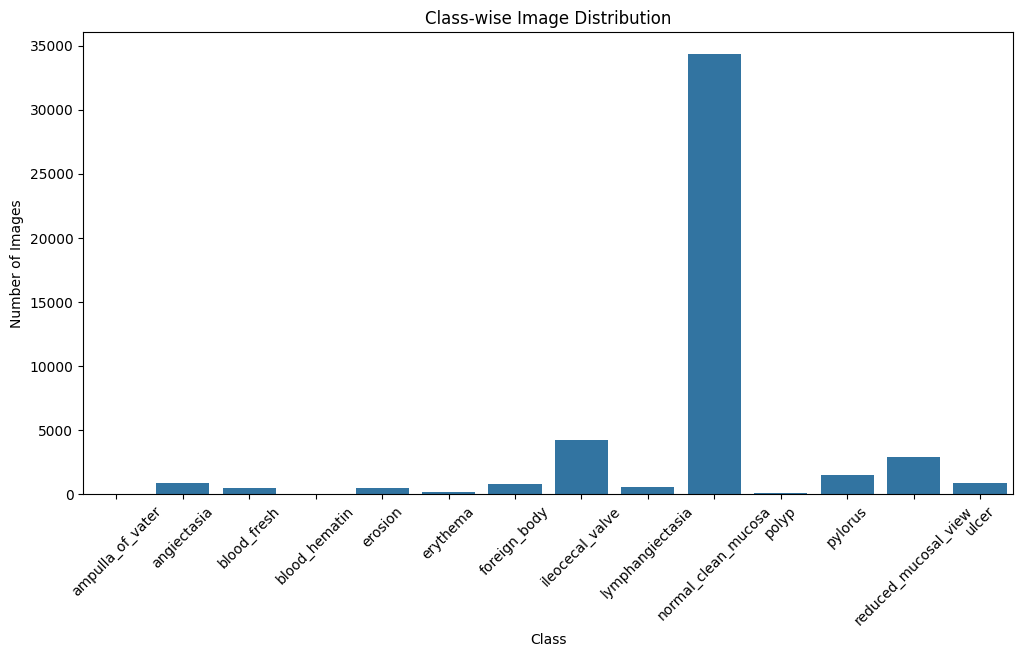

In [4]:
plt.figure(figsize=(12,6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.title("Class-wise Image Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [5]:
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1])

minority = sorted_classes[:3]
majority = sorted_classes[-3:]

print("Minority Classes:", minority)
print("Majority Classes:", majority)

Minority Classes: [('ampulla_of_vater', 10), ('blood_hematin', 12), ('polyp', 55)]
Majority Classes: [('reduced_mucosal_view', 2906), ('ileocecal_valve', 4189), ('normal_clean_mucosa', 34338)]


In [6]:
UNDER_DIR = "Data_Undersampled"
os.makedirs(UNDER_DIR, exist_ok=True)

THRESHOLD = 200

for cls in classes:
    src = os.path.join(DATA_DIR, cls)
    dst = os.path.join(UNDER_DIR, cls)
    os.makedirs(dst, exist_ok=True)

    images = os.listdir(src)

    if len(images) > THRESHOLD:
        images = random.sample(images, THRESHOLD)

    for img in images:
        shutil.copy(os.path.join(src, img), os.path.join(dst, img))

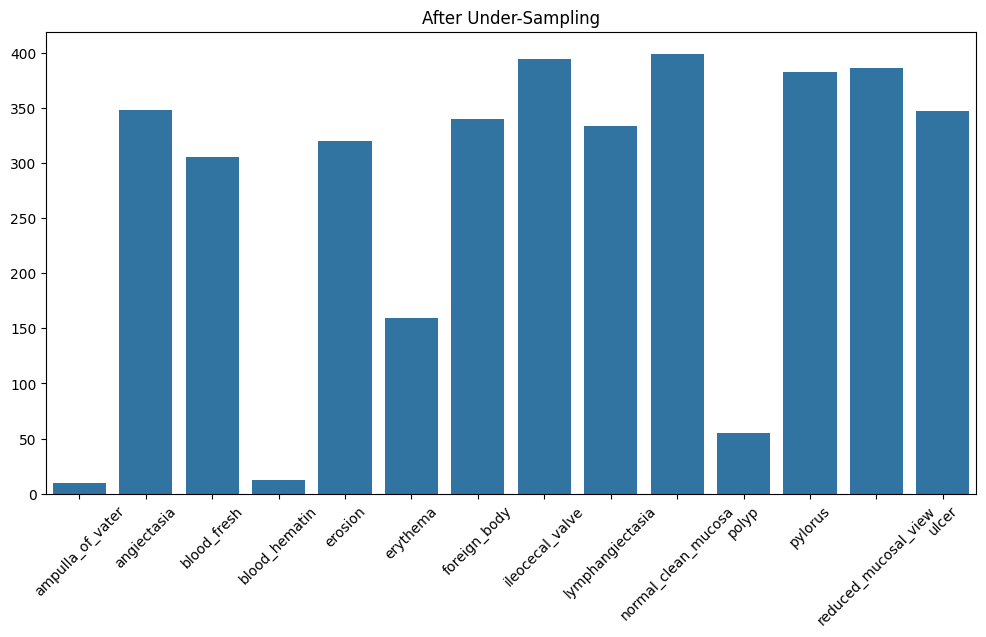

In [7]:
new_counts = {}

for cls in classes:
    new_counts[cls] = len(os.listdir(os.path.join(UNDER_DIR, cls)))

plt.figure(figsize=(12,6))
sns.barplot(x=list(new_counts.keys()), y=list(new_counts.values()))
plt.xticks(rotation=45)
plt.title("After Under-Sampling")
plt.show()

In [8]:
augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
])

In [9]:
AUG_DIR = "Data_Augmented"
os.makedirs(AUG_DIR, exist_ok=True)

target_size = 200

for cls, count in new_counts.items():
    src = os.path.join(UNDER_DIR, cls)
    dst = os.path.join(AUG_DIR, cls)
    os.makedirs(dst, exist_ok=True)

    images = os.listdir(src)

    for img in images:
        shutil.copy(os.path.join(src, img), os.path.join(dst, img))

    if count < target_size:
        needed = target_size - count

        for i in range(needed):
            img_name = random.choice(images)
            img_path = os.path.join(src, img_name)

            img = Image.open(img_path).convert("RGB")
            aug_img = augment(img)

            aug_img.save(os.path.join(dst, f"aug_{i}_{img_name}"))

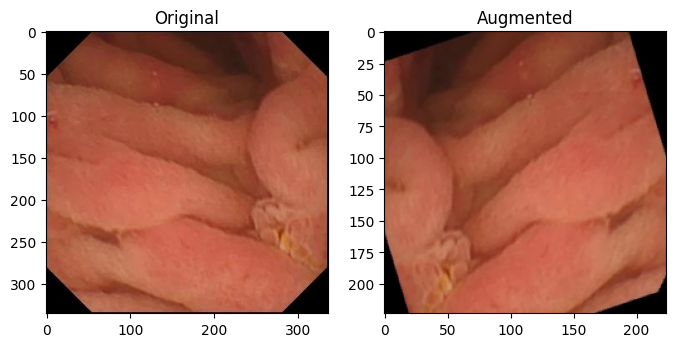

In [10]:
import matplotlib.pyplot as plt

sample_class = classes[0]

img_path = os.path.join(UNDER_DIR, sample_class, os.listdir(os.path.join(UNDER_DIR, sample_class))[0])
img = Image.open(img_path)

aug_img = augment(img)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(aug_img)
plt.title("Augmented")

plt.show()

In [11]:
final_counts = {}

for cls in classes:
    final_counts[cls] = len(os.listdir(os.path.join(AUG_DIR, cls)))

final_counts

{'ampulla_of_vater': 363,
 'angiectasia': 348,
 'blood_fresh': 305,
 'blood_hematin': 378,
 'erosion': 320,
 'erythema': 241,
 'foreign_body': 340,
 'ileocecal_valve': 394,
 'lymphangiectasia': 333,
 'normal_clean_mucosa': 399,
 'polyp': 344,
 'pylorus': 382,
 'reduced_mucosal_view': 386,
 'ulcer': 347}

In [12]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [13]:
dataset = datasets.ImageFolder(AUG_DIR, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

In [14]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [18]:
def get_model(name, num_classes):
    if name == "efficientnet":
        model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    elif name == "mobilenet":
        model = models.mobilenet_v2(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )

    elif name == "inception":
        model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
        model.aux_logits = False
        model.AuxLogits = None
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unsupported model name: {name}")

    return model

In [19]:
def freeze_layers(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in list(model.parameters())[-10:]:
        param.requires_grad = True

    return model

In [20]:
model_names = ["efficientnet", "mobilenet", "inception"]
num_classes = len(classes)

for name in model_names:
    temp_model = get_model(name, num_classes)
    temp_model = freeze_layers(temp_model)

    trainable = sum(p.numel() for p in temp_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in temp_model.parameters())

    print(f"{name.upper()} -> Trainable: {trainable} | Total: {total}")

EFFICIENTNET -> Trainable: 855822 | Total: 4025482
MOBILENET -> Trainable: 739854 | Total: 2241806
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\Himal Rana/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:14<00:00, 7.48MB/s] 

INCEPTION -> Trainable: 866190 | Total: 21814254


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

EPOCHS = 5
model_histories = {}
trained_models = {}

Using device: cuda


In [22]:
def train_one_model(model_name, epochs=5):
    model = get_model(model_name, len(classes))
    model = freeze_layers(model).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "lrs": []
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(train_loader, desc=f"{model_name.upper()} Epoch {epoch}/{epochs} [Train]", leave=False)
        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        val_bar = tqdm(val_loader, desc=f"{model_name.upper()} Epoch {epoch}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                val_bar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_train_loss = train_loss / train_total
        epoch_val_loss = val_loss / val_total
        epoch_train_acc = train_correct / train_total
        epoch_val_acc = val_correct / val_total

        scheduler.step(epoch_val_loss)

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)
        history["lrs"].append(optimizer.param_groups[0]["lr"])

        print(
            f"[{model_name.upper()}] Epoch {epoch}/{epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
        )

    return model, history

for name in model_names:
    print(f"\n===== Training {name.upper()} =====")
    trained_model, history = train_one_model(name, epochs=EPOCHS)
    trained_models[name] = trained_model
    model_histories[name] = history


===== Training EFFICIENTNET =====


[EFFICIENTNET] Epoch 1/5 | Train Loss: 1.0551 | Train Acc: 0.6947 | Val Loss: 0.4373 | Val Acc: 0.8743


[EFFICIENTNET] Epoch 2/5 | Train Loss: 0.3980 | Train Acc: 0.8838 | Val Loss: 0.2953 | Val Acc: 0.9030


[EFFICIENTNET] Epoch 3/5 | Train Loss: 0.2642 | Train Acc: 0.9192 | Val Loss: 0.2430 | Val Acc: 0.9290


[EFFICIENTNET] Epoch 4/5 | Train Loss: 0.1887 | Train Acc: 0.9438 | Val Loss: 0.2171 | Val Acc: 0.9303


...

[INCEPTION] Epoch 1/5 | Train Loss: 1.3991 | Train Acc: 0.5907 | Val Loss: 0.7812 | Val Acc: 0.7678


[INCEPTION] Epoch 2/5 | Train Loss: 0.6788 | Train Acc: 0.8039 | Val Loss: 0.5663 | Val Acc: 0.8115


[INCEPTION] Epoch 3/5 | Train Loss: 0.4451 | Train Acc: 0.8671 | Val Loss: 0.5352 | Val Acc: 0.8443


[INCEPTION] Epoch 4/5 | Train Loss: 0.3298 | Train Acc: 0.9084 | Val Loss: 0.4889 | Val Acc: 0.8388


[INCEPTION] Epoch 5/5 | Train Loss: 0.2381 | Train Acc: 0.9324 | Val Loss: 0.4502 | Val Acc: 0.8607


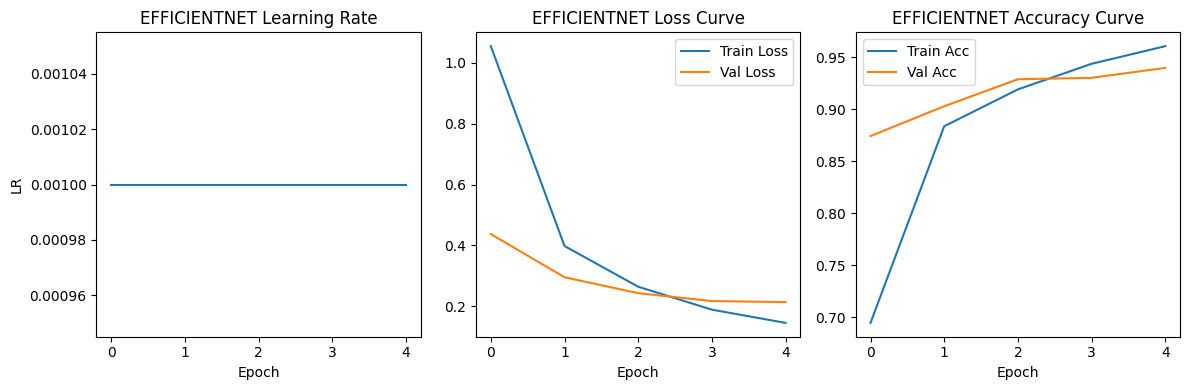

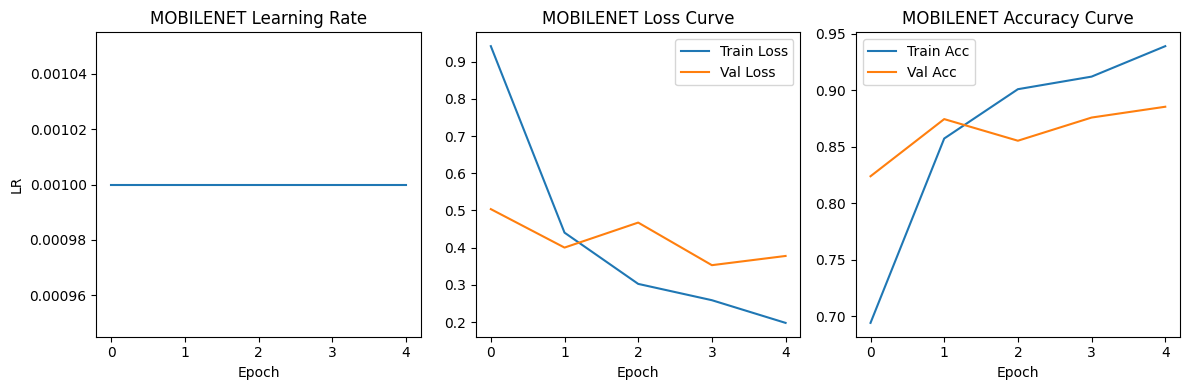

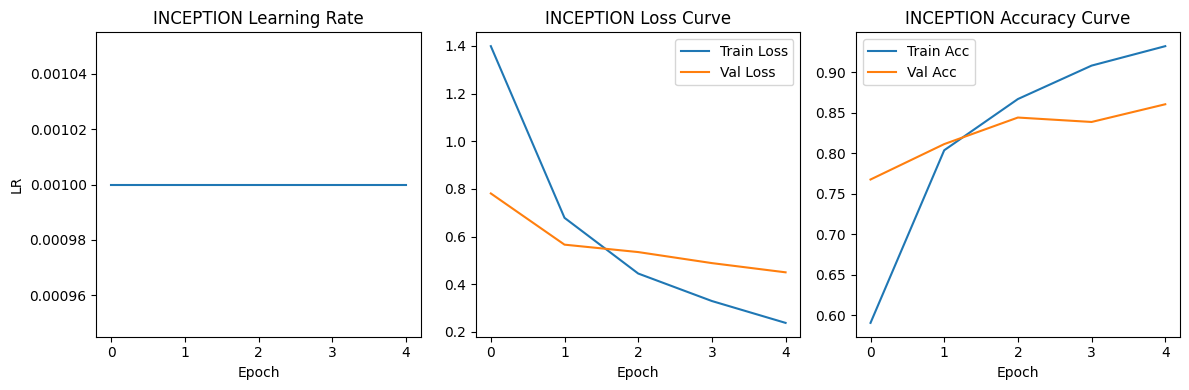

In [23]:
for name, hist in model_histories.items():
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.plot(hist["lrs"])
    plt.title(f"{name.upper()} Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")

    plt.subplot(1,3,2)
    plt.plot(hist["train_loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.title(f"{name.upper()} Loss Curve")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1,3,3)
    plt.plot(hist["train_acc"], label="Train Acc")
    plt.plot(hist["val_acc"], label="Val Acc")
    plt.title(f"{name.upper()} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [24]:
def evaluate(model, loader):
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, axis=1).cpu().numpy()

            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    return y_true, y_pred


===== Test Evaluation: EFFICIENTNET =====
                      precision    recall  f1-score   support

    ampulla_of_vater       0.98      1.00      0.99        56
         angiectasia       0.91      0.91      0.91        43
         blood_fresh       1.00      0.93      0.96        44
       blood_hematin       1.00      1.00      1.00        56
             erosion       0.94      0.84      0.88        55
            erythema       0.91      0.94      0.92        31
        foreign_body       0.95      0.93      0.94        45
     ileocecal_valve       0.83      0.86      0.84        69
    lymphangiectasia       0.96      0.92      0.94        48
 normal_clean_mucosa       0.72      0.82      0.77        57
               polyp       0.98      1.00      0.99        47
             pylorus       0.91      0.88      0.89        56
reduced_mucosal_view       0.91      0.88      0.89        72
               ulcer       0.93      1.00      0.96        53

            accuracy     

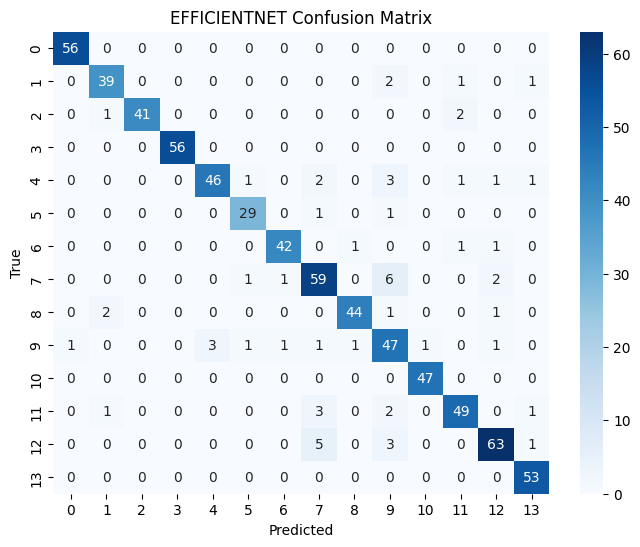


===== Test Evaluation: MOBILENET =====
                      precision    recall  f1-score   support

    ampulla_of_vater       1.00      0.96      0.98        56
         angiectasia       0.80      0.84      0.82        43
         blood_fresh       0.98      0.91      0.94        44
       blood_hematin       1.00      1.00      1.00        56
             erosion       0.91      0.91      0.91        55
            erythema       0.93      0.90      0.92        31
        foreign_body       0.81      0.93      0.87        45
     ileocecal_valve       0.79      0.87      0.83        69
    lymphangiectasia       0.91      0.88      0.89        48
 normal_clean_mucosa       0.74      0.60      0.66        57
               polyp       1.00      1.00      1.00        47
             pylorus       0.68      0.89      0.77        56
reduced_mucosal_view       0.95      0.72      0.82        72
               ulcer       0.89      0.92      0.91        53

            accuracy        

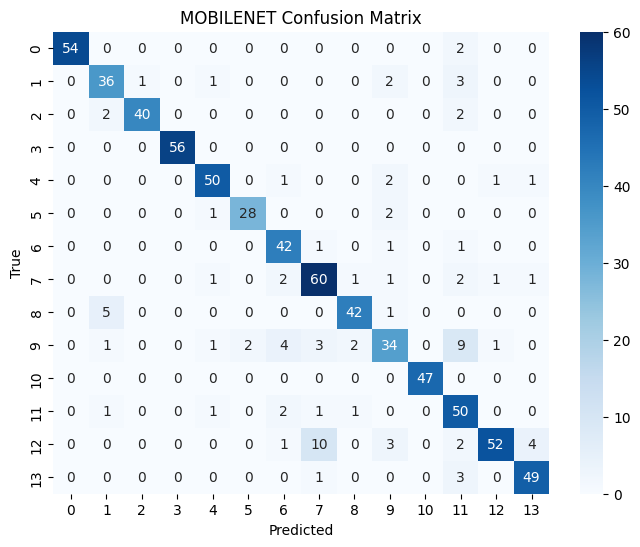


===== Test Evaluation: INCEPTION =====
                      precision    recall  f1-score   support

    ampulla_of_vater       1.00      1.00      1.00        56
         angiectasia       0.76      0.88      0.82        43
         blood_fresh       0.95      0.89      0.92        44
       blood_hematin       1.00      1.00      1.00        56
             erosion       0.89      0.71      0.79        55
            erythema       0.87      0.84      0.85        31
        foreign_body       0.78      0.89      0.83        45
     ileocecal_valve       0.81      0.78      0.79        69
    lymphangiectasia       0.89      0.88      0.88        48
 normal_clean_mucosa       0.67      0.65      0.66        57
               polyp       0.98      1.00      0.99        47
             pylorus       0.69      0.77      0.73        56
reduced_mucosal_view       0.81      0.85      0.83        72
               ulcer       0.88      0.83      0.85        53

            accuracy        

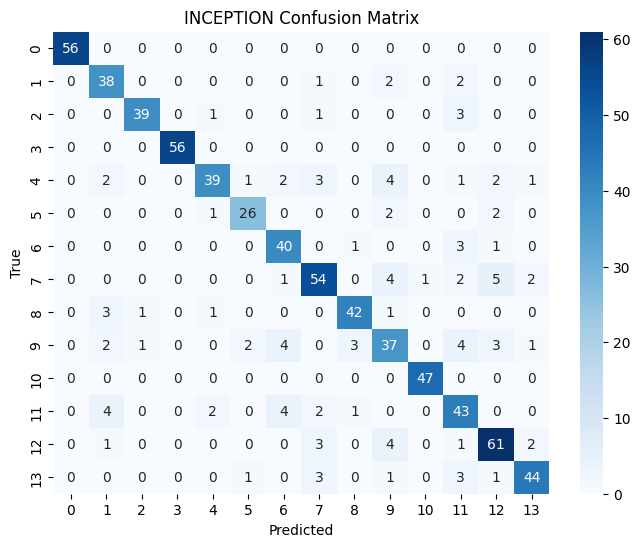

In [25]:
for name, trained_model in trained_models.items():
    print(f"\n===== Test Evaluation: {name.upper()} =====")
    y_true, y_pred = evaluate(trained_model, test_loader)

    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name.upper()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()